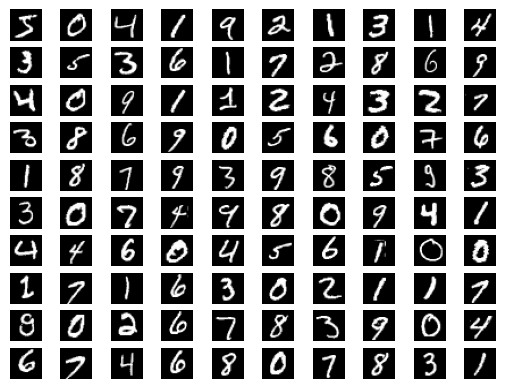

In [30]:
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt

mndata = MNIST(
    '/Users/boo/Desktop/coding/Deep_Learning/MNIST')
mndata.gz = True
# loading training data and testing data
x_train, _ = mndata.load_training()
x_test, _ = mndata.load_testing()
# visualize the data
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0
fig, axs = plt.subplots(10, 10)
for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Reshape x_train and x_test to have two dimensional shape, where
first dimension corresponds to number of training examples 
and second dimension corresponds to flattened size of each example

shape of image -> width and height 
in this case 28 x 28
```
x_train.shape[1:] = (28,28)
```

calculate 28*28 
```
np.prod(x_train.shape[1:]) = 784
```

counting number of example in training set
```
len(x_train)
```

In [13]:
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [14]:
input_dim = x_train.shape[1] # setting input dimension of data (784)
hidden_dim1 = 32 # setting first hidden layer dimension (32)
hidden_dim2 = 64 # setting second hidden layer dimension (64)
hidden_dim3 = 128 # setting third latent space (128)
output_dim = input_dim # setting output dimension of data (784)

# Initialize the weight matrices and biases
W1 = np.random.randn(input_dim, hidden_dim1) * 0.01
b1 = np.zeros((1, hidden_dim1))
W2 = np.random.randn(hidden_dim1, hidden_dim2) * 0.01
b2 = np.zeros((1, hidden_dim2))
W3 = np.random.randn(hidden_dim2, hidden_dim3) * 0.01
b3 = np.zeros((1, hidden_dim3))
W4 = np.random.randn(hidden_dim3, output_dim) * 0.01
b4 = np.zeros((1, output_dim))

In [17]:
def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [18]:
def encoder(x):
    z1 = np.dot(x, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)
    z3 = np.dot(a2, W3) + b3
    a3 = relu(z3)
    return a3, a2, a1, z3, z2, z1

def decoder(x):
    z4 = np.dot(x, W4) + b4
    a4 = sigmoid(z4)
    return a4

Gradient Decent Following this formular
![Gradient Descent Formular](image.png)

In [20]:
num_epochs = 121 # setting number of epochs
batch_size = 256 # setting batch size
num_batches = x_train.shape[0] // batch_size # setting number of batches
learning_rate = 0.0001 # setting learning rate

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in range(num_batches):
        batch_indices = np.random.choice(x_train.shape[0], batch_size)
        # create small batch
        x_batch = x_train[batch_indices]
        # forward pass
        a3, a2, a1, z3, z2, z1 = encoder(x_batch)
        x_hat = decoder(a3)
        # compute loss
        loss = np.mean((x_hat - x_batch)**2)
        total_loss += loss

        # for some reason my loop calculate loss did not working
        # so i wrote it in this manual way

        # backward pass gradient computation 
        dL_dx_hat = x_hat - x_batch # derivative of loss w.r.t. x_hat

        # x_hat * (1- x_hat) is the derivative of sigmoid function
        dL_dz4 = dL_dx_hat * x_hat * (1 - x_hat) # derivative of loss w.r.t. z4
        dL_dW4 = np.dot(a3.T, dL_dz4) # derivative of loss w.r.t. W4
        dL_db4 = np.sum(dL_dz4, axis=0, keepdims=True) # derivative of loss w.r.t. b4

        dL_da3 = np.dot(dL_dz4, W4.T) # derivative of loss w.r.t. a3
        # (z3 > 0) is the derivative of relu function
        dL_dz3 = dL_da3 * (z3 > 0) # derivative of loss w.r.t. z3
        dL_dW3 = np.dot(a2.T, dL_dz3) # derivative of loss w.r.t. W3
        dL_db3 = np.sum(dL_dz3, axis=0, keepdims=True) # derivative of loss w.r.t. b3


        dL_da2 = np.dot(dL_dz3, W3.T) # derivative of loss w.r.t. a2
        # (z2 > 0) is the derivative of relu function
        dL_dz2 = dL_da2 * (z2 > 0) # derivative of loss w.r.t. z2
        dL_dW2 = np.dot(a1.T, dL_dz2) # derivative of loss w.r.t. W2
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True) # derivative of loss w.r.t. b2

        dL_da1 = np.dot(dL_dz2, W2.T) # derivative of loss w.r.t. a1
        # (z1 > 0) is the derivative of relu function
        dL_dz1 = dL_da1 * (z1 > 0) # derivative of loss w.r.t. z1
        dL_dW1 = np.dot(x_batch.T, dL_dz1) # derivative of loss w.r.t. W1
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True) # derivative of loss w.r.t. b1

        # Update the weights and biases
        W1 -= learning_rate * dL_dW1
        b1 -= learning_rate * dL_db1
        W2 -= learning_rate * dL_dW2
        b2 -= learning_rate * dL_db2
        W3 -= learning_rate * dL_dW3
        b3 -= learning_rate * dL_db3
        W4 -= learning_rate * dL_dW4
        b4 -= learning_rate * dL_db4
    if epoch % 10 == 0:
        print("Epoch %d: loss = %f" % (epoch, total_loss))


Epoch 0: loss = 15.525684
Epoch 10: loss = 11.182839
Epoch 20: loss = 6.511694
Epoch 30: loss = 4.825688
Epoch 40: loss = 3.894702
Epoch 50: loss = 3.372820
Epoch 60: loss = 3.036407
Epoch 70: loss = 2.804810
Epoch 80: loss = 2.613599
Epoch 90: loss = 2.419934
Epoch 100: loss = 2.328964
Epoch 110: loss = 2.227845
Epoch 120: loss = 2.150633


plot input and decoded output

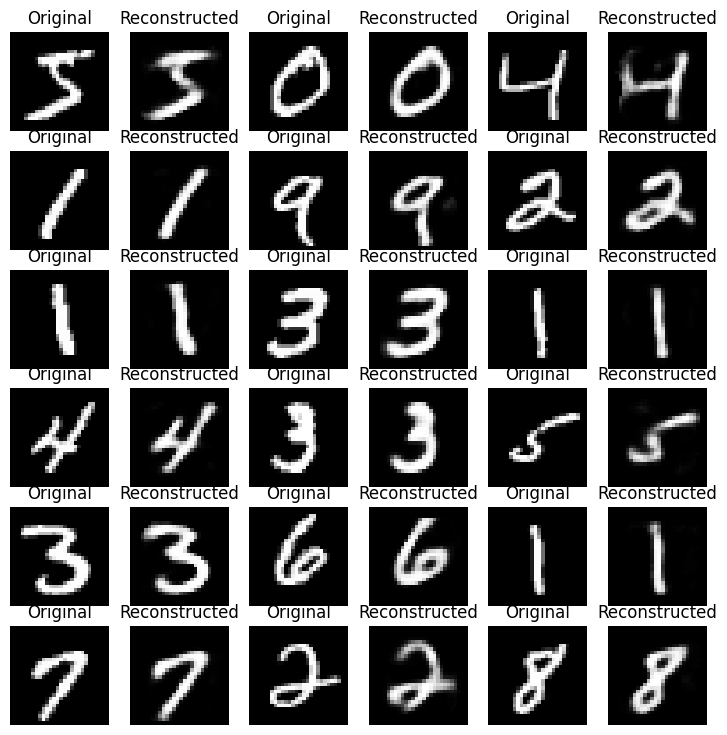

In [31]:
fig, axs = plt.subplots(6, 6, figsize=(9, 9))
x_hat = decoder(encoder(x_train)[0])
for i in range(6):
    for j in range(3):
        # Plot the original image
        ax = axs[i, j*2]
        ax.imshow(x_train[i*3+j].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[i, j*2+1]
        ax.imshow(x_hat[i*3+j].reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')
    
plt.show()



Plot some incorrect case of training set

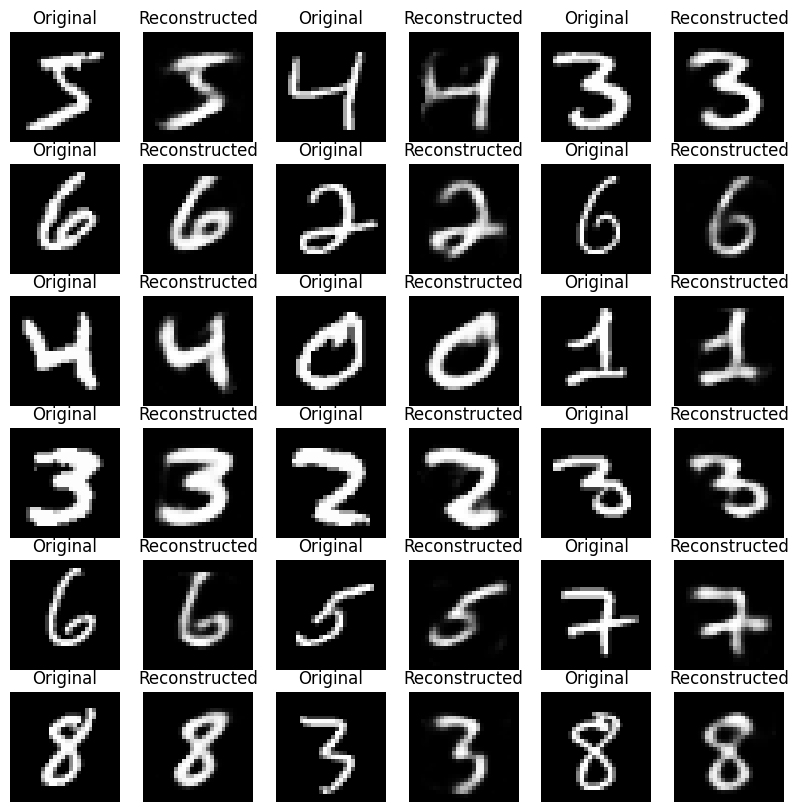

In [33]:
threshold = 0.01
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
x_hat = decoder(encoder(x_train)[0])
count = 0
for i in range(len(x_train)):
    # Compute the reconstructed image
    x_hat_i = x_hat[i]

    # Compute the difference between the input and reconstructed images
    diff = np.mean((x_train[i] - x_hat_i)**2)

    # Plot the input and reconstructed images if the difference is above the threshold
    if diff > threshold:
        # Plot the original image
        ax = axs[count // 3, (count % 3) * 2]
        ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[count // 3, (count % 3) * 2 + 1]
        ax.imshow(x_hat_i.reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')

        count += 1

        # Break out of the loop if we have plotted 18 error cases
        if count == 18:
            break

plt.show()

Testing the Trained Model

In [35]:
        
encoded_imgs, _, _, _, _, _ = encoder(x_test)
decoded_imgs = decoder(encoded_imgs)
print("Loss = %f" % np.mean((x_test - decoded_imgs)**2))


Loss = 0.009259


Plot some incorrect case of test set 

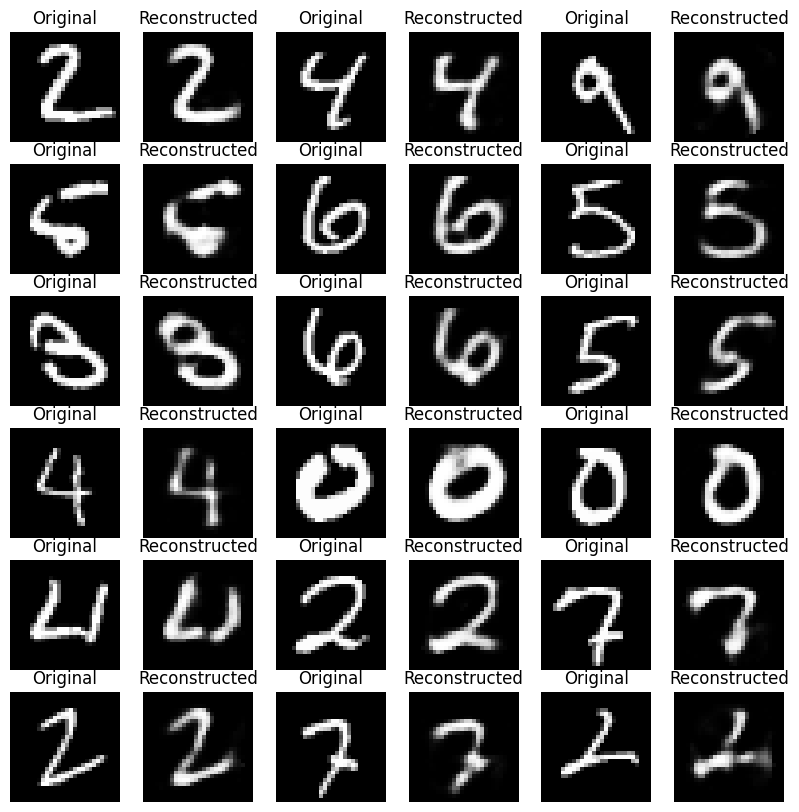

In [36]:
threshold = 0.01
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
x_hat = decoded_imgs
count = 0
for i in range(len(x_test)):
    # Compute the reconstructed image
    x_hat_i = x_hat[i]

    # Compute the difference between the input and reconstructed images
    diff = np.mean((x_test[i] - x_hat_i)**2)

    # Plot the input and reconstructed images if the difference is above the threshold
    if diff > threshold:
        # Plot the original image
        ax = axs[count // 3, (count % 3) * 2]
        ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[count // 3, (count % 3) * 2 + 1]
        ax.imshow(x_hat_i.reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')

        count += 1

        # Break out of the loop if we have plotted 18 error cases
        if count == 18:
            break

plt.show()